
LFSR 再生ボタン付きシミュレータ開始
次数       : 8
規約多項式 : G(x) = x^8 + x^6 + x^5 + x^4 + 1
タップ     : [1, 2, 3, 7]
初期値     : 11110001
理論周期   : 2^8 - 1 = 255
ステップ数 : 20
以後、自動実行します。

出力系列
10001111010000111111


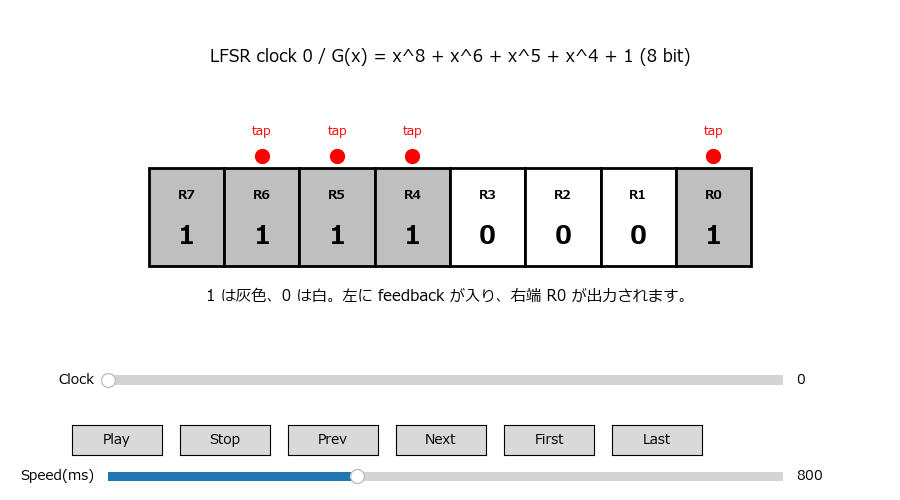

In [7]:
import random
import time
import sys
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.widgets import Button, Slider

matplotlib.rcParams["font.family"] = "Meiryo"
matplotlib.rcParams["axes.unicode_minus"] = False

AUTO_MODE = False
STEPS = 20
player = None

PRIMITIVE_POLYNOMIALS = {
    4:  [[4, 1, 0], [4, 3, 0]],
    5:  [[5, 2, 0], [5, 4, 2, 1, 0]],
    6:  [[6, 1, 0], [6, 5, 0]],
    7:  [[7, 1, 0], [7, 3, 0]],
    8:  [[8, 4, 3, 2, 0], [8, 6, 5, 4, 0]],
    10: [[10, 3, 0], [10, 7, 0]],
    12: [[12, 6, 4, 1, 0]],
    16: [[16, 12, 3, 1, 0], [16, 5, 3, 2, 0]],
    24: [[24, 4, 3, 1, 0]],
    32: [[32, 22, 2, 1, 0]],
    48: [[48, 28, 27, 1, 0]],
    64: [[64, 4, 3, 1, 0]],
}


def wait_next():
    global AUTO_MODE
    time.sleep(random.uniform(1.0, 2.0))

    if AUTO_MODE:
        return

    ans = input("\n次へ進みますか？ [Y/n/a] : ").strip().lower()

    if ans in ("", "y", "yes"):
        return
    if ans in ("a", "auto"):
        AUTO_MODE = True
        print("以後、自動実行します。")
        return
    if ans in ("n", "no"):
        print("\nシミュレーションを終了します。")
        sys.exit(0)

    print("入力が認識できません。続行します。")


def line(title=""):
    print("\n" + "=" * 70)
    if title:
        print(title)
        print("=" * 70)


def bits_to_str(bits):
    return "".join(str(b) for b in bits)


def polynomial_to_string(exponents):
    terms = []
    for e in sorted(exponents, reverse=True):
        if e == 0:
            terms.append("1")
        elif e == 1:
            terms.append("x")
        else:
            terms.append(f"x^{e}")
    return " + ".join(terms)


def choose_random_primitive_polynomial():
    degree = random.choice(list(PRIMITIVE_POLYNOMIALS.keys()))
    exponents = random.choice(PRIMITIVE_POLYNOMIALS[degree])
    return degree, exponents


def polynomial_to_taps(degree, exponents):
    taps = []
    for e in exponents:
        if e == degree:
            continue
        if e == 0:
            taps.append(degree - 1)
        else:
            taps.append(degree - 1 - e)
    return sorted(set(taps))


def random_seed_bits(degree):
    while True:
        seed = [random.randint(0, 1) for _ in range(degree)]
        if any(seed):
            return seed


def draw_register_on_axis(
    ax,
    reg,
    full_length,
    title="LFSR",
    taps=None,
    feedback_value=None,
    output_bit=None,
    max_show=64,
):
    ax.clear()

    if len(reg) > max_show:
        shown = reg[:max_show]
        note = f"先頭 {max_show} bit のみ表示 / 全体 {full_length} bit"
    else:
        shown = reg
        note = f"{full_length} bit"

    shown_n = len(shown)

    for i, bit in enumerate(shown):
        face = "#BFBFBF" if bit == 1 else "white"

        rect = Rectangle(
            (i, 0),
            1,
            1,
            facecolor=face,
            edgecolor="black",
            linewidth=2
        )
        ax.add_patch(rect)

        ax.text(
            i + 0.5,
            0.72,
            f"R{full_length - 1 - i}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

        ax.text(
            i + 0.5,
            0.30,
            str(bit),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold"
        )

        if taps is not None and i in taps:
            ax.plot(
                i + 0.5,
                1.12,
                marker="o",
                markersize=10,
                color="red"
            )

            ax.text(
                i + 0.5,
                1.34,
                "tap",
                ha="center",
                fontsize=9,
                color="red"
            )

    info = []
    if feedback_value is not None:
        info.append(f"feedback = {feedback_value}")
    if output_bit is not None:
        info.append(f"output = {output_bit}")

    if info:
        ax.text(
            shown_n / 2,
            1.68,
            "    ".join(info),
            ha="center",
            fontsize=12
        )

    ax.text(
        shown_n / 2,
        -0.35,
        "1 は灰色、0 は白。左に feedback が入り、右端 R0 が出力されます。",
        ha="center",
        fontsize=11
    )

    margin = max(1.5, shown_n * 0.08)

    ax.set_xlim(-margin, shown_n + margin)
    ax.set_ylim(-0.7, 2.0)

    # 配置崩れ防止のため、set_aspect("equal") は使わない
    ax.axis("off")
    ax.set_title(f"{title} ({note})")


class LFSR:
    def __init__(self, seed, taps, exponents):
        if all(b == 0 for b in seed):
            raise ValueError("LFSRの初期値をすべて0にはできません。")

        self.reg = seed[:]
        self.taps = taps[:]
        self.exponents = exponents[:]
        self.degree = len(seed)

    def step(self):
        before = self.reg[:]
        tap_values = [before[t] for t in self.taps]

        feedback = 0
        for v in tap_values:
            feedback ^= v

        output_bit = before[-1]
        self.reg = [feedback] + before[:-1]

        return {
            "before": before,
            "after": self.reg[:],
            "tap_values": tap_values,
            "feedback": feedback,
            "output_bit": output_bit
        }

    def run_collect(self, steps=20):
        states = [self.reg[:]]
        outputs = []
        feedbacks = [None]
        output_bits = [None]

        for _ in range(steps):
            info = self.step()
            states.append(info["after"])
            outputs.append(info["output_bit"])
            feedbacks.append(info["feedback"])
            output_bits.append(info["output_bit"])

        return states, outputs, feedbacks, output_bits


class LFSRPlayer:
    def __init__(
        self,
        states,
        taps,
        exponents,
        feedbacks,
        output_bits,
        interval_ms=800
    ):
        self.states = states
        self.taps = taps
        self.exponents = exponents
        self.feedbacks = feedbacks
        self.output_bits = output_bits
        self.index = 0
        self.playing = False
        self.interval_ms = interval_ms

        n = len(states[0])
        shown_n = min(n, 64)

        fig_width = max(9, min(18, shown_n * 0.42))

        self.fig, self.ax = plt.subplots(figsize=(fig_width, 5.0))
        plt.subplots_adjust(
            left=0.04,
            right=0.96,
            top=0.86,
            bottom=0.33
        )

        ax_play  = plt.axes([0.08, 0.09, 0.10, 0.06])
        ax_stop  = plt.axes([0.20, 0.09, 0.10, 0.06])
        ax_prev  = plt.axes([0.32, 0.09, 0.10, 0.06])
        ax_next  = plt.axes([0.44, 0.09, 0.10, 0.06])
        ax_first = plt.axes([0.56, 0.09, 0.10, 0.06])
        ax_last  = plt.axes([0.68, 0.09, 0.10, 0.06])

        self.btn_play = Button(ax_play, "Play")
        self.btn_stop = Button(ax_stop, "Stop")
        self.btn_prev = Button(ax_prev, "Prev")
        self.btn_next = Button(ax_next, "Next")
        self.btn_first = Button(ax_first, "First")
        self.btn_last = Button(ax_last, "Last")

        ax_slider = plt.axes([0.12, 0.22, 0.75, 0.04])
        self.slider = Slider(
            ax_slider,
            "Clock",
            0,
            len(states) - 1,
            valinit=0,
            valstep=1
        )

        ax_speed = plt.axes([0.12, 0.03, 0.75, 0.035])
        self.speed_slider = Slider(
            ax_speed,
            "Speed(ms)",
            100,
            2000,
            valinit=interval_ms,
            valstep=100
        )

        self.btn_play.on_clicked(self.on_play)
        self.btn_stop.on_clicked(self.on_stop)
        self.btn_prev.on_clicked(self.on_prev)
        self.btn_next.on_clicked(self.on_next)
        self.btn_first.on_clicked(self.on_first)
        self.btn_last.on_clicked(self.on_last)

        self.slider.on_changed(self.on_slider)
        self.speed_slider.on_changed(self.on_speed_change)

        self.timer = self.fig.canvas.new_timer(interval=self.interval_ms)
        self.timer.add_callback(self.on_timer)

        self.draw()

    def draw(self):
        state = self.states[self.index]
        feedback = self.feedbacks[self.index]
        output_bit = self.output_bits[self.index]

        title = (
            f"LFSR clock {self.index} / "
            f"G(x) = {polynomial_to_string(self.exponents)}"
        )

        draw_register_on_axis(
            ax=self.ax,
            reg=state,
            full_length=len(self.states[0]),
            title=title,
            taps=self.taps,
            feedback_value=feedback,
            output_bit=output_bit
        )

        self.fig.canvas.draw_idle()

    def set_index(self, idx):
        self.index = max(0, min(int(idx), len(self.states) - 1))

        self.slider.eventson = False
        self.slider.set_val(self.index)
        self.slider.eventson = True

        self.draw()

    def on_play(self, event):
        self.playing = True
        self.timer.start()

    def on_stop(self, event):
        self.playing = False
        self.timer.stop()

    def on_prev(self, event):
        self.on_stop(event)
        self.set_index(self.index - 1)

    def on_next(self, event):
        self.on_stop(event)
        self.set_index(self.index + 1)

    def on_first(self, event):
        self.on_stop(event)
        self.set_index(0)

    def on_last(self, event):
        self.on_stop(event)
        self.set_index(len(self.states) - 1)

    def on_slider(self, value):
        self.on_stop(None)
        self.set_index(int(value))

    def on_speed_change(self, value):
        self.interval_ms = int(value)
        self.timer.interval = self.interval_ms

    def on_timer(self):
        if not self.playing:
            return True

        if self.index >= len(self.states) - 1:
            self.index = 0
        else:
            self.index += 1

        self.set_index(self.index)
        return True


def main():
    global player

    line("LFSR 再生ボタン付きシミュレータ開始")

    degree, exponents = choose_random_primitive_polynomial()
    taps = polynomial_to_taps(degree, exponents)
    seed = random_seed_bits(degree)
    theoretical_period = 2 ** degree - 1

    print("次数       :", degree)
    print("規約多項式 :", f"G(x) = {polynomial_to_string(exponents)}")
    print("タップ     :", taps)
    print("初期値     :", bits_to_str(seed))
    print("理論周期   :", f"2^{degree} - 1 = {theoretical_period}")
    print("ステップ数 :", STEPS)

    wait_next()

    lfsr = LFSR(seed=seed, taps=taps, exponents=exponents)
    states, outputs, feedbacks, output_bits = lfsr.run_collect(steps=STEPS)

    line("出力系列")
    print(bits_to_str(outputs))

    player = LFSRPlayer(
        states=states,
        taps=taps,
        exponents=exponents,
        feedbacks=feedbacks,
        output_bits=output_bits,
        interval_ms=800
    )

    plt.show()


if __name__ == "__main__":
    main()